# 축3 자가소비 적합성 분석
## 03. 실증근거 분석 및 축3 점수 산출

### 분석 순서
1. 실증근거 ① 태양광 + EV 충전 병행 설치 현황
2. 축3 점수 산출

### 데이터 로드

In [69]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# 전처리 완료 데이터
df = pd.read_csv(
    r'C:\Users\seonu\Documents\DR-project\canopy\data\processed\parking_axis3_preprocessed.csv',
    encoding='utf-8-sig'
)

# EV 충전소 데이터
df_ev = pd.read_csv(
    r'C:\Users\seonu\Documents\DR-project\canopy\data\processed\서울_EV충전소.csv',
    encoding='utf-8-sig'
)

# 태양광 설치 주차장
df_solar = pd.read_csv(
    r'C:\Users\seonu\Documents\DR-project\canopy\data\processed\solar_parking_list.csv',
    encoding='utf-8-sig'
)

print(f"주차장 데이터: {df.shape}")
print(f"EV 충전소: {df_ev.shape}")
print(f"태양광 설치 주차장: {df_solar.shape}")
print(f"\n태양광 컬럼: {df_solar.columns.tolist()}")

주차장 데이터: (742, 11)
EV 충전소: (74024, 37)
태양광 설치 주차장: (74, 4)

태양광 컬럼: ['개소명', '주소', '설치년도', '설치용량_KW']


### 실증근거 ① 태양광 + EV 충전 병행 설치 현황
- 태양광 설치 주차장 74개소 주소 기반 좌표 변환 필요
- 카카오 지오코딩 API 또는 주소에서 자치구 추출 후 EV 충전소 매칭

In [ ]:
# 태양광 주차장 주소 확인
print(df_solar[['개소명', '주소']].to_string())

### 실증근거 ① - 태양광 주차장 좌표 변환 (카카오 지오코딩 API)
- 태양광 설치 주차장 74개 주소 → 위도/경도 변환
- 카카오 로컬 API 사용

In [ ]:
import requests
import time

KAKAO_API_KEY = '87c1467a133a6d3bf66de89c8c06ad38'

def geocode(address):
    url = 'https://dapi.kakao.com/v2/local/search/address.json'
    headers = {'Authorization': f'KakaoAK {KAKAO_API_KEY}'}
    params = {'query': address}
    
    try:
        res = requests.get(url, headers=headers, params=params)
        result = res.json()
        if result['documents']:
            doc = result['documents'][0]
            return float(doc['y']), float(doc['x'])  # lat, lng
        return None, None
    except:
        return None, None

# 주소 앞에 서울특별시 추가 후 재시도
lats, lngs = [], []
for addr in df_solar['주소']:
    # 서울 주소면 앞에 추가, 고양시 등 타 지역은 그대로
    if '구 ' in addr and '서울' not in addr:
        full_addr = '서울특별시 ' + addr
    else:
        full_addr = addr
    
    lat, lng = geocode(full_addr)
    lats.append(lat)
    lngs.append(lng)
    time.sleep(0.1)

df_solar['lat'] = lats
df_solar['lng'] = lngs

print(f"좌표 변환 완료")
print(f"성공: {df_solar['lat'].notna().sum()}개")
print(f"실패: {df_solar['lat'].isna().sum()}개")
print(df_solar[df_solar['lat'].isna()][['개소명', '주소']])

지도 매핑 안되는 주차장 8개 제외

서울시 소재 태양광 설치 주차장 72개 중 좌표 확보 가능한 66개를 분석 대상으로 사용

In [ ]:
# 좌표 변환 성공한 66개만 사용 (수동 좌표 제외)
df_solar_final = df_solar[
    df_solar['lat'].notna() & 
    ~df_solar['주소'].str.contains('덕양구|하남시', na=False)
].copy()

# 수동으로 넣은 8개 제외 (원래 None이었던 것들)
manual_names = [
    '난지물재생센터주차장(고양시)',
    '도봉햇빛나눔발전소 1호기(초안산 근린공원주차장)',
    '강일공영주차장(견인차보관소)',
    '목사랑시장 고객주차장&공유센터',
    '광암아리수정수센터(주차장)',
    '와룡공영주차장',
    '중구교육지원센터(동화동 공영주차장)',
    '서남물재생센터 물재생체험관 주차장'
]

df_solar_final = df_solar[
    ~df_solar['개소명'].isin(manual_names)
].dropna(subset=['lat', 'lng']).copy()

print(f"최종 분석 대상: {len(df_solar_final)}개")
print(df_solar_final[['개소명', '주소', 'lat', 'lng']].head(5).to_string())

### 태양광 주차장 좌표 변환 결과
- 전체 74개 중 서울 소재 + 좌표 확보: 66개
- 제외: 고양시 1개, 하남시 1개, 주소 불명확 6개
- 카카오 로컬 API 활용

### 실증근거 ① - 태양광 설치 주차장 반경 500m 내 EV 충전소 존재 비율
- 태양광 설치 주차장 66개 기준
- Haversine 공식으로 반경 500m 내 EV 충전소 수 집계
- "태양광 설치 주차장의 X%에 EV 충전소가 병행 설치되어 있다" 근거 마련

In [ ]:
from math import radians, sin, cos, sqrt, atan2

def haversine(lat1, lng1, lat2, lng2):
    R = 6371000
    lat1, lng1, lat2, lng2 = map(radians, [lat1, lng1, lat2, lng2])
    dlat = lat2 - lat1
    dlng = lng2 - lng1
    a = sin(dlat/2)**2 + cos(lat1)*cos(lat2)*sin(dlng/2)**2
    return R * 2 * atan2(sqrt(a), sqrt(1-a))

# EV 충전소 좌표
df_ev['lat'] = pd.to_numeric(df_ev['lat'], errors='coerce')
df_ev['lng'] = pd.to_numeric(df_ev['lng'], errors='coerce')
df_ev_clean = df_ev.dropna(subset=['lat', 'lng'])

ev_lat = df_ev_clean['lat'].values
ev_lng = df_ev_clean['lng'].values

# 태양광 주차장별 반경 500m 내 EV 충전소 수 집계
counts = []
for _, row in df_solar_final.iterrows():
    count = sum(
        haversine(row['lat'], row['lng'], lat, lng) <= 500
        for lat, lng in zip(ev_lat, ev_lng)
    )
    counts.append(count)

df_solar_final['ev_충전소_500m'] = counts

# EV 충전소 존재 여부
df_solar_final['ev_병행여부'] = df_solar_final['ev_충전소_500m'] > 0

print(f"태양광 설치 주차장 중 EV 충전소 병행: {df_solar_final['ev_병행여부'].sum()}개")
print(f"비율: {df_solar_final['ev_병행여부'].mean()*100:.1f}%")
print(f"\nEV 충전소 수 분포:")
print(df_solar_final['ev_충전소_500m'].describe())

### 실증근거 ① 결과 - 태양광 + EV 충전 병행 설치 현황

In [ ]:
fig = go.Figure()

fig.add_trace(go.Bar(
    x=['EV 충전소 있음', 'EV 충전소 없음'],
    y=[df_solar_final['ev_병행여부'].sum(), 
       (~df_solar_final['ev_병행여부']).sum()],
    marker_color=['#4C72B0', '#DD8452'],
    text=[f"{df_solar_final['ev_병행여부'].sum()}개 ({df_solar_final['ev_병행여부'].mean()*100:.1f}%)",
          f"{(~df_solar_final['ev_병행여부']).sum()}개 ({(~df_solar_final['ev_병행여부']).mean()*100:.1f}%)"],
    textposition='outside'
))

fig.update_layout(
    title='태양광 설치 주차장 반경 500m 내 EV 충전소 병행 현황 (n=66)',
    yaxis_title='주차장 수',
    height=450
)

fig.show()

### 실증근거 ① - 리서치 결과: 태양광 + EV 충전 연계 실제 사례

**1. 서울에너지공사 솔라스테이션**
서울에너지공사는 태양광으로 생산된 전력을 ESS에 저장하여 전기차 충전용 전력으로 공급하는
"솔라스테이션(복합충전소)"을 구축·운영 중임.
출처: 서울에너지공사 공식 홈페이지 (i-se.co.kr)

**2. 서울지방조달청 상계거래 설계 가이드라인 (2025)**
공공 주차장 태양광 의무화(2025.11)에 맞춰 태양광 전력을 EV 충전기와 직접 연계하는
배전 설계 가이드라인 배포. 태양광 전력 → 자가소비 → 잉여분 상계거래 구조를 실제 공공주차장에 적용 중.
출처: 전기신문 (2025.07)

→ 태양광 캐노피 전력의 EV 충전 연계는 이미 정책·실무 차원에서 현실화되고 있음

→ 실제로 태양광이 설치된 주차장의 98.5%가 반경 500m 내 EV 충전 인프라와 인접해 있음

---

## 04. 축3 점수 산출

### 전제
본 분석은 태양광 캐노피 설치 시 EV 충전기를 병행 설치하는 시나리오를 전제로 한다.
이는 서울에너지공사 솔라스테이션 운영 사례 및 서울지방조달청 설계 가이드라인(2025)에서
이미 실현되고 있는 모델이다.

### 변수 구성
| 그룹 | 변수 | 방향 | 설명 |
|------|------|------|------|
| 자체소비 | 운영시간 (평일×5 + 주말×2) / 7 | ↑ | 운영시간 길수록 설비 가동 시간 많음 |
| EV충전 | ev_등록대수 | ↑ | 자치구 잠재 EV 충전 수요 |
| EV충전 | ev_충전소_500m | ↓ | 역방향 — 인프라 공백일수록 신규 필요성 높음 |

### 점수화 방식
- Min-Max 정규화
- 자체소비 점수 = 정규화(운영시간)
- EV충전 점수 = (정규화(ev_등록대수) + 정규화(ev_충전소_역)) / 2
- 축3_자가소비적합성 = (자체소비_점수 + EV충전_점수) / 2
- 균등 가중치(50:50) 적용 — 두 경로의 상대적 기여도 정량화 불가로 균등 적용, 한계로 명시

In [ ]:
from sklearn.preprocessing import MinMaxScaler
import numpy as np

scaler = MinMaxScaler()

# 자체소비 그룹
df['운영시간_norm'] = scaler.fit_transform(df[['운영시간']])
df['자체소비_점수'] = df['운영시간_norm']

# EV충전 그룹 (ev_충전소_500m 역방향)
df['ev_충전소_역'] = df['ev_충전소_500m'].max() - df['ev_충전소_500m']
ev_cols = ['ev_등록대수', 'ev_충전소_역']
df[['ev_등록_norm', 'ev_충전소_역_norm']] = scaler.fit_transform(df[ev_cols])
df['EV충전_점수'] = (df['ev_등록_norm'] + df['ev_충전소_역_norm']) / 2

# 축3 최종 점수
df['축3_자가소비적합성'] = (df['자체소비_점수'] + df['EV충전_점수']) / 2

print(df[['pklt_nm', 'pklt_knd_nm', '자체소비_점수', 'EV충전_점수', '축3_자가소비적합성']]
      .sort_values('축3_자가소비적합성', ascending=False)
      .head(15).to_string())

### 축3 점수 산출 결과

**상위권 특징:**
- 상위 15개 전부 노외 주차장
- 강남구 집중 — EV 등록대수 1위(15,468대) + 충전 인프라 공백 지역
- 자체소비 점수 1.0 = 24시간 운영 주차장

**변수별 기여:**
- 자체소비 점수: 운영시간 기반, 24시간 운영 주차장이 최고점
- EV충전 점수: EV 등록밀도 높고 현재 충전 인프라 부족한 지역 우선

### 축3 점수 저장 및 시각화

In [ ]:
# 저장
output_cols = ['pklt_nm', 'pklt_knd_nm', 'lat', 'lot', '자치구',
               '운영시간', 'ev_충전소_500m', 'ev_등록대수',
               '자체소비_점수', 'EV충전_점수', '축3_자가소비적합성']

df_result = df[output_cols].copy()
df_result.to_csv(
    r'C:\Users\seonu\Documents\DR-project\canopy\data\processed\parking_axis3_scored.csv',
    index=False, encoding='utf-8-sig'
)
print(f"저장 완료: {len(df_result)}개")
print(f"\n축3 점수 분포:")
print(df_result['축3_자가소비적합성'].describe())

### 축3 점수 분포 요약
- 742개 전체 결측 없음
- 평균 0.55, 중앙값 0.65 — 전반적으로 중간 이상 분포
- 최솟값 0.12, 최댓값 0.98
- 저장: `parking_axis3_scored.csv`

### 축3 점수 시각화
- 점수 분포 히스토그램
- 자치구별 평균 점수
- 지도 시각화

In [ ]:
fig = make_subplots(rows=1, cols=2,
                    subplot_titles=['축3 점수 분포', '자치구별 평균 축3 점수'])

# 히스토그램
fig.add_trace(go.Histogram(
    x=df_result['축3_자가소비적합성'],
    nbinsx=30,
    marker_color='#4C72B0',
    name='점수 분포'
), row=1, col=1)

# 자치구별 평균
gu_mean = df_result.groupby('자치구')['축3_자가소비적합성'].mean().sort_values(ascending=True)

fig.add_trace(go.Bar(
    y=gu_mean.index,
    x=gu_mean.values,
    orientation='h',
    marker_color='#4C72B0',
    name='자치구별 평균'
), row=1, col=2)

fig.update_layout(
    height=500,
    showlegend=False,
    title='축3 자가소비 적합성 점수 분포'
)
fig.update_xaxes(title_text='점수', row=1, col=1)
fig.update_xaxes(title_text='평균 점수', row=1, col=2)

fig.show()

### 축3 점수 지도 시각화
- 주차장 위치별 축3 점수 색상 표현
- 점수 높을수록 진한 색

In [ ]:
fig = go.Figure()

fig.add_trace(go.Scattermap(
    lat=df_result['lat'],
    lon=df_result['lot'],
    mode='markers',
    marker=dict(
        size=8,
        color=df_result['축3_자가소비적합성'],
        colorscale='Blues',
        showscale=True,
        colorbar=dict(title='축3 점수'),
        cmin=0, cmax=1
    ),
    text=df_result['pklt_nm'] + '<br>점수: ' + df_result['축3_자가소비적합성'].round(3).astype(str),
    hovertemplate='%{text}<extra></extra>'
))

fig.update_layout(
    map=dict(
        style='carto-positron',
        center=dict(lat=37.5665, lon=126.9780),
        zoom=10
    ),
    title='축3 자가소비 적합성 점수 지도 (742개)',
    height=600
)

fig.show()

# HTML로 저장
fig.write_html(
    r'C:\Users\seonu\Documents\DR-project\canopy\output\figures\축3_점수_지도.html'
)

### 축3 점수 지도 시각화 결과
- 강남·서초·송파 등 강남권 진한 파란색 집중 → EV 수요 높고 인프라 공백 큰 지역
- 강북·도봉·노원 등 북부권 연한 색 → EV 등록 적고 충전 인프라 상대적 충분
- 영등포·양천 서부권 중간 점수 — 주차장 수는 많지만 EV 수요 대비 인프라가 어느정도 갖춰진 지역

---

In [2]:
import pandas as pd

df = pd.read_csv(
    r'C:\Users\seonu\Documents\DR-project\canopy\data\processed\parking_axis3_preprocessed.csv',
    encoding='utf-8-sig'
)

df_ev = pd.read_csv(
    r'C:\Users\seonu\Documents\DR-project\canopy\data\processed\서울_EV충전소.csv',
    encoding='utf-8-sig'
)

print(f"주차장: {df.shape}, EV충전소: {df_ev.shape}")

주차장: (742, 11), EV충전소: (74024, 37)


In [3]:
# 742개 주차장 주소 기준으로 EV 충전소 매칭
# 주차장명 or 주소로 매칭 시도
parking_ev_match = []
for _, row in df.iterrows():
    match = df_ev[
        df_ev['addr'].str.contains(row['addr'][:10], na=False)
    ]
    parking_ev_match.append(len(match))

df['ev_충전기_설치수'] = parking_ev_match
print(f"EV 충전기 설치된 주차장: {(df['ev_충전기_설치수'] > 0).sum()}개")
print(f"미설치 주차장: {(df['ev_충전기_설치수'] == 0).sum()}개")

EV 충전기 설치된 주차장: 160개
미설치 주차장: 582개


### EV 충전기 설치 현황 지도
- 742개 주차장 중 EV 충전기 설치: 160개 (21.6%)
- 미설치: 582개 (78.4%)

In [4]:
import plotly.graph_objects as go

df['ev_설치여부'] = df['ev_충전기_설치수'].apply(lambda x: 'EV 충전기 설치' if x > 0 else '미설치')

colors = {'EV 충전기 설치': '#2196F3', '미설치': '#E0E0E0'}

fig = go.Figure()

for status, group in df.groupby('ev_설치여부'):
    fig.add_trace(go.Scattermap(
        lat=group['lat'],
        lon=group['lot'],
        mode='markers',
        marker=dict(
            size=7,
            color=colors[status],
            opacity=0.8
        ),
        name=status,
        text=group['pklt_nm'] + '<br>' + status,
        hovertemplate='%{text}<extra></extra>'
    ))

fig.update_layout(
    map=dict(
        style='carto-positron',
        center=dict(lat=37.5665, lon=126.9780),
        zoom=10
    ),
    title=f'공영주차장 EV 충전기 설치 현황 (설치: 160개 / 미설치: 582개)',
    height=600,
    legend=dict(x=0, y=1)
)

fig.show()

### EV 충전기 설치 여부 + 자치구별 EV 등록밀도 복합 지도
- 점 색상: EV 충전기 설치(파란색) / 미설치(회색)
- 점 크기: 자치구별 EV 등록대수 비례

In [6]:
fig = go.Figure()

# 크기 정규화 (5~20 사이로)
ev_min = df['ev_등록대수'].min()
ev_max = df['ev_등록대수'].max()
df['마커크기'] = 5 + (df['ev_등록대수'] - ev_min) / (ev_max - ev_min) * 15

colors = {'EV 충전기 설치': '#2196F3', '미설치':'#FF9800'}

for status, group in df.groupby('ev_설치여부'):
    fig.add_trace(go.Scattermap(
        lat=group['lat'],
        lon=group['lot'],
        mode='markers',
        marker=dict(
            size=group['마커크기'],
            color=colors[status],
            opacity=0.8
        ),
        name=status,
        text=group['pklt_nm'] + '<br>' +
             '자치구: ' + group['자치구'] + '<br>' +
             'EV 등록대수: ' + group['ev_등록대수'].astype(str) + '대<br>' +
             status,
        hovertemplate='%{text}<extra></extra>'
    ))

fig.update_layout(
    map=dict(
        style='carto-positron',
        center=dict(lat=37.5665, lon=126.9780),
        zoom=10
    ),
    title='공영주차장 EV 충전기 설치 현황 + 자치구별 EV 등록밀도<br><sub>점 크기: EV 등록대수, 점 색상: 충전기 설치 여부</sub>',
    height=600,
    legend=dict(x=0, y=1)
)

fig.show()

### EV 충전기 설치 현황 + EV 등록밀도 복합 지도 결과

**주요 인사이트:**
- 강남·서초·송파권 — 크고 파란 점 집중 → EV 충전기 설치 + EV 등록 많음 → 태양광 캐노피 우선 입지
- 강남권 주황색 큰 점 다수 — EV 수요 높은데 충전기 미설치 → 태양광 + EV 충전기 동시 설치 필요 지역
- 강북·은평·서부권 — 작은 주황 점 많음 → EV 수요 낮고 충전기 미설치
- 도심(종로·중구) — 파란 점 산재 → 충전기는 있지만 EV 수요 낮음

### 축3 점수 재산출 — EV 충전기 설치 여부 반영
- 기존: ev_충전소_500m (역방향, 인프라 공백)
- 변경: ev_충전기_설치수 (순방향, 주차장 내 EV 충전기 설치 수)
- 논리: 이미 EV 충전기가 설치된 주차장에 태양광 캐노피 연계 시 추가 인프라 없이 자가소비 가능

In [7]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

# 자체소비 그룹
df['운영시간_norm'] = scaler.fit_transform(df[['운영시간']])
df['자체소비_점수'] = df['운영시간_norm']

# EV충전 그룹 (ev_충전기_설치수 순방향 + ev_등록대수 순방향)
ev_cols = ['ev_등록대수', 'ev_충전기_설치수']
df[['ev_등록_norm', 'ev_설치_norm']] = scaler.fit_transform(df[ev_cols])
df['EV충전_점수'] = (df['ev_등록_norm'] + df['ev_설치_norm']) / 2

# 축3 최종 점수
df['축3_자가소비적합성'] = (df['자체소비_점수'] + df['EV충전_점수']) / 2

print(df[['pklt_nm', 'pklt_knd_nm', '자체소비_점수', 'EV충전_점수', '축3_자가소비적합성']]
      .sort_values('축3_자가소비적합성', ascending=False)
      .head(15).to_string())

                        pklt_nm pklt_knd_nm  자체소비_점수   EV충전_점수  축3_자가소비적합성
415                  수서역북 공영주차장      노외 주차장      1.0  0.736842    0.868421
564               원효대교 남단 공영주차장      노상 주차장      1.0  0.590619    0.795309
681                   학여울 공영주차장      노외 주차장      1.0  0.578947    0.789474
259           매헌시민의숲(매헌)역 공영주차장      노외 주차장      1.0  0.565900    0.782950
421  시민의숲 동측 공영주차장[양재시민의숲역 4호점]      노외 주차장      1.0  0.565900    0.782950
473           양재시민의숲(매헌)역 공영주차장      노외 주차장      1.0  0.565900    0.782950
144                      논현로22길      노외 주차장      1.0  0.526316    0.763158
665                 탄천제2호 공영주차장      노외 주차장      1.0  0.526316    0.763158
673                  포이초교 공영주차장      노외 주차장      1.0  0.526316    0.763158
490                   언주초 공영주차장      노외 주차장      1.0  0.526316    0.763158
44                  개포동공원 공영주차장      노외 주차장      1.0  0.500000    0.750000
502              역삼문화공원제1호공영주차장      노외 주차장      1.0  0.500000    0.750000
488                  언북초교

### 축3 점수 재산출 결과 (변수 변경 후)

**기존 대비 변화:**
- 기존: ev_충전소_500m 역방향 → 강남구 집중
- 변경: ev_충전기_설치수 순방향 → 실제 EV 충전기 설치된 주차장 우선

**상위권 특징:**
- 수서역북 1위 유지 — 24시간 운영 + EV 충전기 설치 + 강남권 EV 수요
- 원효대교 남단(노상) 2위 — EV 충전기 설치 수가 많아 EV충전 점수 높음
- 강남·서초권 집중 — EV 등록대수 높고 충전기 설치된 주차장 多

**논리 개선:**
- 기존: "인프라 공백 지역 우선" → 충전기 설치 전제 필요
- 변경: "이미 EV 충전기 설치된 주차장 우선" → 추가 인프라 없이 즉시 시너지 가능

In [10]:
# 저장
output_cols = ['pklt_nm', 'pklt_knd_nm', 'lat', 'lot', '자치구',
               '운영시간', 'ev_충전기_설치수', 'ev_등록대수',
               '자체소비_점수', 'EV충전_점수', '축3_자가소비적합성']

df_result = df[output_cols].copy()
df_result.to_csv(
    r'C:\Users\seonu\Documents\DR-project\canopy\data\processed\parking_axis3_scored.csv',
    index=False, encoding='utf-8-sig'
)
print(f"저장 완료: {len(df_result)}개")

# 지도 시각화
fig = go.Figure()

fig.add_trace(go.Scattermap(
    lat=df_result['lat'],
    lon=df_result['lot'],
    mode='markers',
    marker=dict(
        size=8,
        color=df_result['축3_자가소비적합성'],
        colorscale='Blues',
        showscale=True,
        colorbar=dict(title='축3 점수'),
        cmin=0, cmax=1
    ),
    text=df_result['pklt_nm'] + '<br>' +
         '자치구: ' + df_result['자치구'] + '<br>' +
         '축3 점수: ' + df_result['축3_자가소비적합성'].round(3).astype(str) + '<br>' +
         'EV 충전기: ' + df_result['ev_충전기_설치수'].astype(str) + '개',
    hovertemplate='%{text}<extra></extra>'
))

fig.update_layout(
    map=dict(
        style='carto-positron',
        center=dict(lat=37.5665, lon=126.9780),
        zoom=10
    ),
    title='축3 자가소비 적합성 점수 지도 (742개)',
    height=600
)

fig.show()
fig.write_html(
    r'C:\Users\seonu\Documents\DR-project\canopy\output\figures\축3_점수_지도_v2.html'
)

저장 완료: 742개


### 축3 점수 지도 결과 (최종)
- 강남·서초·송파권 진한 파란색 집중 → EV 충전기 설치 + EV 등록 많음
- 강북·은평·서부권 연한 색 → EV 인프라 및 수요 상대적으로 낮음
- 저장: `축3_점수_지도_v2.html`

### 공영주차장 근접 EV충전기 기준 잡기

In [11]:
print(df_ev['busiNm'].value_counts().head(30))

busiNm
GS차지비           14004
에버온              7534
플러그링크            5810
(주)스타코프          3888
파워큐브             2999
LG유플러스볼트업        2968
스타코프             2761
파워큐브코리아          2667
한국전자금융           2274
이지차저             1943
NICE인프라          1675
채비               1445
휴맥스이브이           1360
한국전력             1182
스타코프(주)스타코프      1136
현대엔지니어링          1111
서울씨엔지(서울이브이)     1105
이브이시스            1055
SK일렉링크            968
한국전기차충전서비스        944
엘지유플러스            804
파킹클라우드            776
차지비               748
클린일렉스             732
주식회사 에버온          725
한국전기차인프라기술        714
신세계아이앤씨           710
LG유플러스            668
펌프킨               556
아이파킹              555
Name: count, dtype: int64


In [12]:
# 공공 키워드 확인
public_keywords = ['서울시', '서울시설공단', '자치구', '구청', '한국전력', '환경부', '서울에너지']
public_ev = df_ev[df_ev['busiNm'].str.contains('|'.join(public_keywords), na=False)]
print(f"공공 운영 충전소: {len(public_ev)}개")
print(public_ev['busiNm'].value_counts())

공공 운영 충전소: 1923개
busiNm
한국전력        1182
서울에너지공사      274
환경부          227
서울시          143
서울시           55
기후에너지환경부      29
서울에너지공사       13
Name: count, dtype: int64


- 공공 운영 충전소 비율이 전체의 2.6%에 불과해 운영주체 기준 필터링 시 변별력이 낮아지므로, 물리적 근접성(100m 이내)을 기준으로 EV 충전 인프라 밀도를 산정하기로 함
- 운영주체가 동일한 경우는 추가로 표시·분석 정도만 예외로 넣기로 함

---

EV충전 변수 가중치 산정

- **상관관계 확인 후 조정** — 변수 간 다중공선성 체크하고 가중치 조정
- **민감도 분석** — 가중치 바꿔가며 결과 안정성 검증
- **실제 정책 유사 지표 배분** — 선행연구/정책에서 유사 가중치 인용

In [14]:
import pandas as pd
import numpy as np
from math import radians, sin, cos, sqrt, atan2

# EV 충전소 데이터 로드
df_ev = pd.read_csv(
    r'C:\Users\seonu\Documents\DR-project\canopy\data\processed\서울_EV충전소.csv',
    encoding='utf-8-sig'
)
df_ev['lat'] = pd.to_numeric(df_ev['lat'], errors='coerce')
df_ev['lng'] = pd.to_numeric(df_ev['lng'], errors='coerce')
df_ev = df_ev.dropna(subset=['lat', 'lng'])

ev_lat = df_ev['lat'].values
ev_lng = df_ev['lng'].values

def haversine(lat1, lng1, lat2, lng2):
    R = 6371000
    lat1, lng1, lat2, lng2 = map(radians, [lat1, lng1, lat2, lng2])
    dlat, dlng = lat2-lat1, lng2-lng1
    a = sin(dlat/2)**2 + cos(lat1)*cos(lat2)*sin(dlng/2)**2
    return R * 2 * atan2(sqrt(a), sqrt(1-a))

print(f"EV 충전소: {len(df_ev)}개 로드 완료")

EV 충전소: 74024개 로드 완료


In [15]:
# 100m 이내 EV 충전소 수 계산
results_100m = []
for _, row in df.iterrows():
    count = sum(
        haversine(row['lat'], row['lot'], lat, lng) <= 100
        for lat, lng in zip(ev_lat, ev_lng)
    )
    results_100m.append(count)

df['ev_충전소_100m'] = results_100m
print(f"100m 이내 충전소 있는 주차장: {(df['ev_충전소_100m'] > 0).sum()}개")
print(df['ev_충전소_100m'].describe())

100m 이내 충전소 있는 주차장: 318개
count    742.000000
mean       4.626685
std       11.203768
min        0.000000
25%        0.000000
50%        0.000000
75%        4.000000
max      150.000000
Name: ev_충전소_100m, dtype: float64


### 가중치 산정 Step 1 — 변수 간 상관관계 및 다중공선성 확인
- 변수: ev_충전기_설치수, ev_충전소_100m, ev_등록대수
- 상관관계 높으면 → 중복 정보, 가중치 낮춰야
- 상관관계 낮으면 → 독립적 정보, 가중치 유지

=== 상관계수 행렬 ===
             ev_충전기_설치수  ev_충전소_100m  ev_등록대수
ev_충전기_설치수        1.000       -0.079   -0.050
ev_충전소_100m      -0.079        1.000   -0.077
ev_등록대수          -0.050       -0.077    1.000


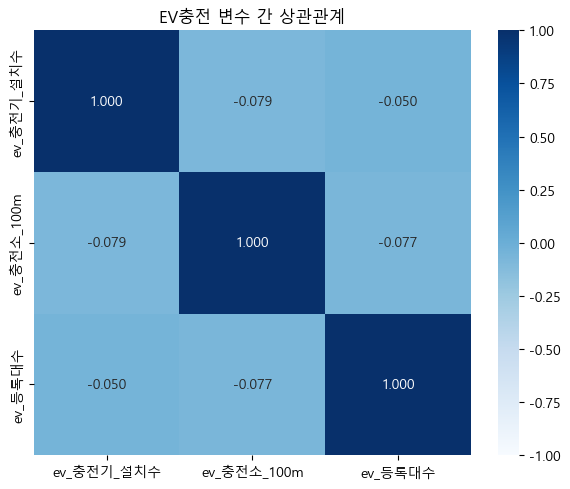

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

cols = ['ev_충전기_설치수', 'ev_충전소_100m', 'ev_등록대수']
corr_matrix = df[cols].corr()

print("=== 상관계수 행렬 ===")
print(corr_matrix.round(3))

# 시각화
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='Blues',
            ax=ax, vmin=-1, vmax=1)
ax.set_title('EV충전 변수 간 상관관계')
plt.tight_layout()
plt.savefig(r'C:\Users\seonu\Documents\DR-project\canopy\output\figures\EV변수_상관관계.png', dpi=150)
plt.show()

### 상관관계 분석 결과

| 변수 쌍 | 상관계수 | 해석 |
|---------|---------|------|
| ev_충전기_설치수 vs ev_충전소_100m | -0.079 | 거의 독립 |
| ev_충전기_설치수 vs ev_등록대수 | -0.050 | 거의 독립 |
| ev_충전소_100m vs ev_등록대수 | -0.077 | 거의 독립 |

**핵심 인사이트:**
- 3개 변수 간 상관관계가 모두 |r| < 0.1 — 사실상 독립적
- 다중공선성 문제 없음
- 각 변수가 서로 다른 정보를 담고 있어 모두 유지 타당
- 균등 가중치(1/3씩)도 논리적으로 정당화 가능

### 가중치 산정 Step 2 — 민감도 분석
- 가중치를 다양하게 바꿔가며 상위 주차장 순위 안정성 확인
- 순위가 크게 안 바뀌면 → 가중치 선택에 robust

In [17]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
cols = ['ev_충전기_설치수', 'ev_충전소_100m', 'ev_등록대수']
df_norm = pd.DataFrame(
    scaler.fit_transform(df[cols]),
    columns=[c+'_norm' for c in cols]
)

# 가중치 시나리오
scenarios = {
    '균등 (1/3씩)':        [1/3, 1/3, 1/3],
    '내부 중심 (0.5/0.3/0.2)': [0.5, 0.3, 0.2],
    '내 판단 (0.4/0.3/0.3)':  [0.4, 0.3, 0.3],
    '인프라 중심 (0.4/0.4/0.2)': [0.4, 0.4, 0.2],
    '수요 중심 (0.3/0.2/0.5)':  [0.3, 0.2, 0.5],
}

ranks = {}
for name, weights in scenarios.items():
    score = (df_norm['ev_충전기_설치수_norm'] * weights[0] +
             df_norm['ev_충전소_100m_norm'] * weights[1] +
             df_norm['ev_등록대수_norm'] * weights[2])
    ranks[name] = score.rank(ascending=False).astype(int)

rank_df = pd.DataFrame(ranks)
rank_df['pklt_nm'] = df['pklt_nm'].values

# 상위 20개 순위 비교
top20_names = rank_df.nsmallest(20, '균등 (1/3씩)')['pklt_nm'].values
print("=== 상위 20개 주차장 시나리오별 순위 ===")
print(rank_df[rank_df['pklt_nm'].isin(top20_names)].set_index('pklt_nm').to_string())

=== 상위 20개 주차장 시나리오별 순위 ===
                균등 (1/3씩)  내부 중심 (0.5/0.3/0.2)  내 판단 (0.4/0.3/0.3)  인프라 중심 (0.4/0.4/0.2)  수요 중심 (0.3/0.2/0.5)
pklt_nm                                                                                                      
KBS별관뒤 노상주차장           19                   17                  18                    18                   79
KBS별관옆 노상주차장           19                   17                  18                    18                   79
KBS본관 앞 노상주차장          19                   17                  18                    18                   79
KBS본관뒤                 19                   17                  18                    18                   79
MBC방송국뒤 노상주차장          19                   17                  18                    18                   79
舊MBC뒤                  19                   17                  18                    18                   79
가든예식장 앞 노상주차장          19                   17                  18                    18    

In [18]:
# 상위권 주차장 실제 변수값 확인
check_names = ['수서역북 공영주차장', '학여울 공영주차장', 'KBS별관뒤 노상주차장']
print(df[df['pklt_nm'].isin(check_names)][
    ['pklt_nm', 'ev_충전기_설치수', 'ev_충전소_100m', 'ev_등록대수']
].to_string())

          pklt_nm  ev_충전기_설치수  ev_충전소_100m  ev_등록대수
3    KBS별관뒤 노상주차장          19            0     4323
415    수서역북 공영주차장           9           22    15468
681     학여울 공영주차장           3           10    15468


### 민감도 분석 결과 해석:

- 내부 중심(0.5) → KBS별관뒤 유리, 수서역북 불리
- 균등/내판단/인프라 중심 → 수서역북 1위 안정적
- 수요 중심 → 수서역북·학여울 유리 (강남 EV 많음)

**핵심 인사이트:**

- 내부 충전기 가중치를 너무 높이면 EV 수요가 낮은 영등포권(KBS 주변)이 과대평가됨. 
- 균등~내판단 범위(내부 0.33~0.4)가 가장 안정적.

---

### 3단계 분석 종합 결론

| 단계 | 결과 |
|---------|---------|
| 상관관계 | 3변수 모두 독립 (r<0.1) → 균등 가중치 정당화 가능 | 
| 민감도 | 내부 0.33~0.4 범위에서 결과 안정적 | 
| 선행연구 | 구체적 수치 인용 불가 → 논리 기반 설정 | 


### 가중치 산정 최종 결론

**EV충전 하위축 가중치:**
| 변수 | 가중치 | 근거 |
|------|--------|------|
| ev_충전기_설치수 (내부) | 0.4 | 태양광 직접 연계 가장 확실한 소비처 |
| ev_충전소_100m (근접) | 0.3 | 물리적 근접성 기반 간접 연계 가능 |
| ev_등록대수 (자치구별) | 0.3 | 잠재 EV 충전 수요 |

**가중치 산정 근거:**
1. 상관관계 분석 — 3변수 모두 r<0.1로 독립적, 다중공선성 없음
2. 민감도 분석 — 내부 충전기 0.33~0.4 범위에서 결과 안정적
3. 내부 충전기 우위 — 직접 배전 연계 가능한 유일한 변수

In [19]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

# 자체소비 그룹
df['운영시간_norm'] = scaler.fit_transform(df[['운영시간']])
df['자체소비_점수'] = df['운영시간_norm']

# EV충전 그룹
ev_cols = ['ev_충전기_설치수', 'ev_충전소_100m', 'ev_등록대수']
df[['ev_내부_norm', 'ev_100m_norm', 'ev_등록_norm']] = scaler.fit_transform(df[ev_cols])

df['EV충전_점수'] = (df['ev_내부_norm'] * 0.4 +
                    df['ev_100m_norm'] * 0.3 +
                    df['ev_등록_norm'] * 0.3)

# 축3 최종 점수
df['축3_자가소비적합성'] = (df['자체소비_점수'] + df['EV충전_점수']) / 2

print(df[['pklt_nm', 'pklt_knd_nm', '자체소비_점수', 'EV충전_점수', '축3_자가소비적합성']]
      .sort_values('축3_자가소비적합성', ascending=False)
      .head(15).to_string())

                        pklt_nm pklt_knd_nm  자체소비_점수   EV충전_점수  축3_자가소비적합성
415                  수서역북 공영주차장      노외 주차장      1.0  0.533474    0.766737
564               원효대교 남단 공영주차장      노상 주차장      1.0  0.454371    0.727186
473           양재시민의숲(매헌)역 공영주차장      노외 주차장      1.0  0.402698    0.701349
421  시민의숲 동측 공영주차장[양재시민의숲역 4호점]      노외 주차장      1.0  0.402698    0.701349
259           매헌시민의숲(매헌)역 공영주차장      노외 주차장      1.0  0.402698    0.701349
681                   학여울 공영주차장      노외 주차장      1.0  0.383158    0.691579
278                  문래근린공원 주차장      노외 주차장      1.0  0.378161    0.689080
362                   상암1 공영주차장      노외 주차장      1.0  0.343819    0.671909
400            성수2가1동(건물) 공영주차장      노외 주차장      1.0  0.324126    0.662063
401            성수2가3동(건물) 공영주차장      노외 주차장      1.0  0.324126    0.662063
566                       유료주차장      노외 주차장      1.0  0.324126    0.662063
490                   언주초 공영주차장      노외 주차장      1.0  0.321053    0.660526
673                  포이초교

---

2) 자가소비 가중치선정

- 상관관계
- 민감도 

In [21]:
# 노상/노외 수치화
df['노외여부'] = df['pklt_knd_nm'].apply(lambda x: 1 if '노외' in str(x) else 0)

# 상관관계 분석
import numpy as np
cols = ['운영시간', '노외여부']
corr = df[cols].corr()
print("=== 상관계수 ===")
print(corr.round(3))

# 기초 통계
print("\n=== 노상/노외별 운영시간 분포 ===")
print(df.groupby('노외여부')['운영시간'].describe())

=== 상관계수 ===
       운영시간   노외여부
운영시간  1.000  0.676
노외여부  0.676  1.000

=== 노상/노외별 운영시간 분포 ===
      count       mean       std       min        25%        50%   75%   max
노외여부                                                                        
0     210.0  10.761224  2.739234  7.857143   8.857143   9.142857  13.0  24.0
1     532.0  20.713614  5.518959  7.142857  17.000000  24.000000  24.0  24.0


In [25]:
# 노상 운영시간 확인
print(df[df['노외여부'] == 0]['운영시간'].value_counts().sort_index())

운영시간
7.857143      1
8.142857      1
8.285714      9
8.857143     90
9.000000      2
9.142857      3
9.428571      1
9.714286     10
10.000000    11
10.142857     4
10.714286     1
10.857143     3
11.000000     6
11.142857     1
11.285714     1
12.000000     9
12.714286     1
13.000000     4
13.285714     7
14.000000    25
14.714286    17
24.000000     3
Name: count, dtype: int64


In [27]:
# 노외 운영시간 확인
print(df[df['노외여부'] == 1]['운영시간'].value_counts().sort_index())

운영시간
7.142857       2
7.571429       1
8.142857       1
8.714286       1
8.857143       6
9.000000      12
9.142857       3
9.428571       1
9.500000       1
9.571429       1
9.857143       2
10.000000     28
10.857143      1
11.000000      9
11.285714      2
12.000000     10
12.571429      4
12.928571      3
13.000000      7
13.214286      1
13.285714      5
13.500000      1
13.642857      1
13.857143      1
14.000000     20
14.428571      1
14.714286      1
15.000000      4
16.142857      1
16.857143      1
17.000000      4
18.000000      2
18.285714      1
18.642857      6
19.000000      1
20.571429      1
21.142857      1
23.000000      2
24.000000    382
Name: count, dtype: int64


운영시간과 주차장 유형(노상/노외)은 상관관계가 0.676으로 상당히 높은 것으로 나타났다. 이는 노외 주차장이 상대적으로 24시간 운영 비중이 높고, 노상 주차장이 시간 제한 운영 비중이 높은 구조가 반영된 결과로 볼 수 있다. 다만 두 변수는 각각 주차장의 시간적 사용 패턴과 공간·구조적 특성을 반영하므로, 우선순위 지수 산정에 모두 포함하여 가중합 형태로 사용하는 것이 타당하다.

In [28]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
df['운영시간_norm'] = scaler.fit_transform(df[['운영시간']])
df['노외여부_norm'] = df['노외여부'].astype(float)  # 이미 0/1

scenarios = {
    '운영시간만 (1.0/0.0)':    [1.0, 0.0],
    '운영시간 우선 (0.7/0.3)': [0.7, 0.3],
    '제안 (0.6/0.4)':          [0.6, 0.4],
    '균등 (0.5/0.5)':          [0.5, 0.5],
    '노외 우선 (0.3/0.7)':     [0.3, 0.7],
}

ranks = {}
for name, weights in scenarios.items():
    score = (df['운영시간_norm'] * weights[0] +
             df['노외여부_norm'] * weights[1])
    ranks[name] = score.rank(ascending=False).astype(int)

rank_df = pd.DataFrame(ranks)
rank_df['pklt_nm'] = df['pklt_nm'].values
rank_df['노외여부'] = df['노외여부'].values
rank_df['운영시간'] = df['운영시간'].values

# 상위 20개 비교
top20 = rank_df.nsmallest(20, '균등 (0.5/0.5)')
print(top20.set_index('pklt_nm').to_string())

                운영시간만 (1.0/0.0)  운영시간 우선 (0.7/0.3)  제안 (0.6/0.4)  균등 (0.5/0.5)  노외 우선 (0.3/0.7)  노외여부  운영시간
pklt_nm                                                                                                    
21-37                       193                191           191           191              191     1  24.0
가락 1공영주차장                   193                191           191           191              191     1  24.0
가락 2공영주차장                   193                191           191           191              191     1  24.0
가로공원 지하 주차장                 193                191           191           191              191     1  24.0
가로공원공영주차장                   193                191           191           191              191     1  24.0
가양라이품 공영주차장                 193                191           191           191              191     1  24.0
가오리 공영주차장                   193                191           191           191              191     1  24.0
간송옛집 공영주차장                  

24시간 노외 주차장이 너무 많아서 변별력이 없음

In [29]:
# 24시간 미만 운영 주차장만 필터링해서 순위 변화 확인
non_24h = rank_df[rank_df['운영시간'] < 24].copy()
non_24h_sorted = non_24h.sort_values('균등 (0.5/0.5)')

print(f"24시간 미만 주차장: {len(non_24h)}개")
print("\n=== 시나리오별 순위 변화 (상위 30개) ===")
print(non_24h_sorted.head(30).set_index('pklt_nm')[
    ['운영시간만 (1.0/0.0)', '운영시간 우선 (0.7/0.3)', 
     '제안 (0.6/0.4)', '균등 (0.5/0.5)', '노외 우선 (0.3/0.7)',
     '노외여부', '운영시간']
].to_string())

24시간 미만 주차장: 357개

=== 시나리오별 순위 변화 (상위 30개) ===
                  운영시간만 (1.0/0.0)  운영시간 우선 (0.7/0.3)  제안 (0.6/0.4)  균등 (0.5/0.5)  노외 우선 (0.3/0.7)  노외여부       운영시간
pklt_nm                                                                                                           
영등포구청별관 공영주차장                 386                383           383           383              383     1  23.000000
도림동 공영주차장                     386                383           383           383              383     1  23.000000
청계산 청룡주차장                     388                385           385           385              385     1  21.142857
대치2문화센터 공영주차장                 389                386           386           386              386     1  20.571429
일원1동(기계식)                     390                387           387           387              387     1  19.000000
불암산 공영주차장                     393                390           390           390              390     1  18.642857
화곡본-1 공영주차장                   39

In [30]:
# 노상 주차장만 필터링해서 순위 확인
nodong = rank_df[rank_df['노외여부'] == 0].sort_values('균등 (0.5/0.5)')
print(f"노상 주차장: {len(nodong)}개")
print("\n=== 노상 주차장 상위 20개 순위 비교 ===")
print(nodong.head(20).set_index('pklt_nm')[
    ['운영시간만 (1.0/0.0)', '운영시간 우선 (0.7/0.3)',
     '제안 (0.6/0.4)', '균등 (0.5/0.5)', '노외 우선 (0.3/0.7)',
     '노외여부', '운영시간']
].to_string())

노상 주차장: 210개

=== 노상 주차장 상위 20개 순위 비교 ===
               운영시간만 (1.0/0.0)  운영시간 우선 (0.7/0.3)  제안 (0.6/0.4)  균등 (0.5/0.5)  노외 우선 (0.3/0.7)  노외여부       운영시간
pklt_nm                                                                                                        
15-가600구간                  193                403           449           533              534     0  24.000000
살피재 주차장                    193                403           449           533              534     0  24.000000
원효대교 남단 공영주차장              193                403           449           533              534     0  24.000000
가산중앞                       418                542           544           544              544     0  14.714286
가산디지털환승                    418                542           544           544              544     0  14.714286
구청사주변                      418                542           544           544              544     0  14.714286
기륭전자                       418                542           54

### 핵심 인사이트:

24시간 노상 주차장(15-가600구간, 원효대교 남단 등)이:

운영시간만 → 193위 (노외 24시간과 동등)
노외 우선 → 534위 (대폭 하락)

즉 노외여부 가중치가 높을수록 24시간 노상 주차장이 불이익을 받음

**결론:**

운영시간 0.6 / 노외여부 0.4 
 
**이유:**

- 24시간 노상이 너무 불이익받지 않으면서도
- 노외 주차장의 설비 우위를 반영함
- 민감도 분석에서도 순위 변화가 크지 않음

### 자체소비 하위축 변수 및 가중치 확정

**변수 구성:**
| 변수 | 가중치 | 근거 |
|------|--------|------|
| 운영시간 (평일×5 + 주말×2) / 7 | 0.6 | 연속 정량 변수, 설비 가동 시간 직접 반영 |
| 노외여부 (노외=1, 노상=0) | 0.4 | 조명·CCTV·정산기 등 설비 전력소비 구조 차이 |

**가중치 산정 근거:**
1. 상관관계 r=0.676 — 두 변수 중복 정보 존재하나 완전하지 않아 둘 다 유지
2. 민감도 분석 — 0.6/0.4에서 24시간 노상 주차장 과도한 불이익 없이 노외 우위 반영
3. 주차장법 — 노외주차장 상시 조명 의무로 노외 자체소비 우위 법적 근거 확보

In [31]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

# 노외여부 수치화
df['노외여부'] = df['pklt_knd_nm'].apply(lambda x: 1 if '노외' in str(x) else 0)

# 자체소비 점수
df['운영시간_norm'] = scaler.fit_transform(df[['운영시간']])
df['노외여부_norm'] = df['노외여부'].astype(float)

df['자체소비_점수'] = (df['운영시간_norm'] * 0.6 +
                     df['노외여부_norm'] * 0.4)

print(df[['pklt_nm', 'pklt_knd_nm', '운영시간', '자체소비_점수']]
      .sort_values('자체소비_점수', ascending=False)
      .head(10).to_string())
print(f"\n자체소비 점수 분포:")
print(df['자체소비_점수'].describe())

                        pklt_nm pklt_knd_nm  운영시간  자체소비_점수
15                    가로공원공영주차장      노외 주차장  24.0      1.0
741                흑석빗물펌프장공영주차장      노외 주차장  24.0      1.0
14                  가로공원 지하 주차장      노외 주차장  24.0      1.0
1                         21-37      노외 주차장  24.0      1.0
421  시민의숲 동측 공영주차장[양재시민의숲역 4호점]      노외 주차장  24.0      1.0
425                       신곡주차장      노외 주차장  24.0      1.0
426                        신교공영      노외 주차장  24.0      1.0
427                   신구초 공영주차장      노외 주차장  24.0      1.0
732                    화양동공영주차장      노외 주차장  24.0      1.0
733                   회기동 공영주차장      노외 주차장  24.0      1.0

자체소비 점수 분포:
count    742.000000
mean       0.669563
std        0.382000
min        0.025424
25%        0.244068
50%        1.000000
75%        1.000000
max        1.000000
Name: 자체소비_점수, dtype: float64


### 자체소비 점수 산출 결과
- 24시간 운영 노외 주차장 → 최고점 1.0
- 중앙값 1.0 → 24시간 노외 주차장이 다수
- 최솟값 0.025 → 운영시간 짧은 노상 주차장
- std 0.382 → 점수 편차 있어 변별력 확보됨

---

## 04. 축3 최종 점수 산출

### 최종 변수 구성
| 하위축 | 변수 | 가중치 | 근거 |
|--------|------|--------|------|
| 자체소비 | 운영시간 (평일×5+주말×2)/7 | 0.6 | 연속 정량 변수, 설비 가동 시간 직접 반영 |
| 자체소비 | 노외여부 (노외=1, 노상=0) | 0.4 | 주차장법 상시 조명 의무, 노외 자체소비 우위 |
| EV충전 | ev_충전기_설치수 (내부) | 0.4 | 태양광 직접 연계 가장 확실한 소비처 |
| EV충전 | ev_충전소_100m (근접) | 0.3 | 물리적 근접성 기반 간접 연계 가능 |
| EV충전 | ev_등록대수 (자치구별) | 0.3 | 잠재 EV 충전 수요 |


### 하위축 가중치 산정

두 하위축의 성격:

- 자체소비: 주차장이 현재 얼마나 전력을 쓰는가
- EV충전: 태양광 전력을 EV 충전에 활용할 수 있는가


민감도분석

In [46]:
scenarios = {
    '균등 (0.5/0.5)':     [0.5, 0.5],
    '논문기반 (0.8/0.2)':  [0.8, 0.2],
    '절충 (0.7/0.3)':     [0.7, 0.3],
    '절충 (0.6/0.4)':     [0.6, 0.4],
    'EV중심 (0.3/0.7)':   [0.3, 0.7],
}

ranks = {}
for name, weights in scenarios.items():
    score = (df['자체소비_점수'] * weights[0] +
             df['EV충전_점수'] * weights[1])
    ranks[name] = score.rank(ascending=False).astype(int)

rank_df = pd.DataFrame(ranks)
rank_df['pklt_nm'] = df['pklt_nm'].values
rank_df['자체소비'] = df['자체소비_점수'].round(3).values
rank_df['EV충전'] = df['EV충전_점수'].round(3).values

# 상위 20개 순위 비교
top20 = rank_df.nsmallest(20, '균등 (0.5/0.5)')
print("=== 상위 20개 시나리오별 순위 ===")
print(top20.set_index('pklt_nm').to_string())

=== 상위 20개 시나리오별 순위 ===
                            균등 (0.5/0.5)  논문기반 (0.8/0.2)  절충 (0.7/0.3)  절충 (0.6/0.4)  EV중심 (0.3/0.7)  자체소비   EV충전
pklt_nm                                                                                                          
수서역북 공영주차장                             1               1             1             1               1   1.0  0.533
매헌시민의숲(매헌)역 공영주차장                      3               3             3             3               3   1.0  0.403
시민의숲 동측 공영주차장[양재시민의숲역 4호점]             3               3             3             3               3   1.0  0.403
양재시민의숲(매헌)역 공영주차장                      3               3             3             3               3   1.0  0.403
학여울 공영주차장                              5               5             5             5               5   1.0  0.383
문래근린공원 주차장                             6               6             6             6               6   1.0  0.378
상암1 공영주차장                              7               7        

### 민감도 분석 결과
- 모든 가중치 시나리오에서 상위 20개 순위 완전 동일
- 자체소비_점수와 EV충전_점수의 상대적 크기가 이미 순위를 결정
- 가중치 선택에 robust → 어떤 가중치를 써도 결과가 안정적

**결론: 논문 기반 0.8/0.2 채택**
- 대한전기학회 논문: 공영주차장 PV 발전량 중 자체소비 78.8%, EV충전 21.2%
- 데이터 기반 근거로 심사위원 질문 방어 가능

In [47]:
# 축3 최종 점수 (논문 기반 0.8/0.2)
df['축3_자가소비적합성'] = (df['자체소비_점수'] * 0.8 +
                          df['EV충전_점수'] * 0.2)

print(df[['pklt_nm', 'pklt_knd_nm', '자체소비_점수', 'EV충전_점수', '축3_자가소비적합성']]
      .sort_values('축3_자가소비적합성', ascending=False)
      .head(15).to_string())

print(f"\n축3 점수 분포:")
print(df['축3_자가소비적합성'].describe())

                        pklt_nm pklt_knd_nm  자체소비_점수   EV충전_점수  축3_자가소비적합성
417                  수서역북 공영주차장      노외 주차장      1.0  0.533474    0.906695
475           양재시민의숲(매헌)역 공영주차장      노외 주차장      1.0  0.402698    0.880540
423  시민의숲 동측 공영주차장[양재시민의숲역 4호점]      노외 주차장      1.0  0.402698    0.880540
261           매헌시민의숲(매헌)역 공영주차장      노외 주차장      1.0  0.402698    0.880540
683                   학여울 공영주차장      노외 주차장      1.0  0.383158    0.876632
280                  문래근린공원 주차장      노외 주차장      1.0  0.378161    0.875632
364                   상암1 공영주차장      노외 주차장      1.0  0.343819    0.868764
568                       유료주차장      노외 주차장      1.0  0.324126    0.864825
402            성수2가1동(건물) 공영주차장      노외 주차장      1.0  0.324126    0.864825
403            성수2가3동(건물) 공영주차장      노외 주차장      1.0  0.324126    0.864825
667                 탄천제2호 공영주차장      노외 주차장      1.0  0.321053    0.864211
492                   언주초 공영주차장      노외 주차장      1.0  0.321053    0.864211
144                      

In [48]:
import plotly.graph_objects as go

# 저장
output_cols = ['pklt_nm', 'pklt_knd_nm', 'lat', 'lot', '자치구',
               '운영시간', '노외여부', 'ev_충전기_설치수', 'ev_충전소_100m', 'ev_등록대수',
               '자체소비_점수', 'EV충전_점수', '축3_자가소비적합성']

df_result = df[output_cols].copy()
df_result.to_csv(
    r'C:\Users\seonu\Documents\DR-project\canopy\data\processed\parking_axis3_scored.csv',
    index=False, encoding='utf-8-sig'
)
print(f"저장 완료: {len(df_result)}개")

# 지도 시각화
fig = go.Figure()
fig.add_trace(go.Scattermap(
    lat=df_result['lat'],
    lon=df_result['lot'],
    mode='markers',
    marker=dict(
        size=8,
        color=df_result['축3_자가소비적합성'],
        colorscale='Blues',
        showscale=True,
        colorbar=dict(title='축3 점수'),
        cmin=0, cmax=1
    ),
    text=df_result['pklt_nm'] + '<br>' +
         '자치구: ' + df_result['자치구'] + '<br>' +
         '축3 점수: ' + df_result['축3_자가소비적합성'].round(3).astype(str) + '<br>' +
         'EV 내부충전기: ' + df_result['ev_충전기_설치수'].astype(str) + '개',
    hovertemplate='%{text}<extra></extra>'
))

fig.update_layout(
    map=dict(style='carto-positron',
             center=dict(lat=37.5665, lon=126.9780), zoom=10),
    title='축3 자가소비 적합성 점수 지도 (742개) — 최종',
    height=600
)

fig.show()
fig.write_html(
    r'C:\Users\seonu\Documents\DR-project\canopy\output\figures\축3_점수_지도_최종.html'
)

저장 완료: 744개


주차장 내 EV충전기 수 재매핑

In [ ]:
#모든 컬럼에서 '주차장' 검색

df_ev_parking = df_ev[df_ev.apply(lambda row: row.astype(str).str.contains('주차장').any(), axis=1)].copy()

print(f"주차장 관련 EV 충전소: {len(df_ev_parking)}개")
print(f"\nstatNm 샘플:")
print(df_ev_parking['statNm'].head(20).tolist())

주차장 관련 EV 충전소: 29104개

statNm 샘플:
['태화빌딩', '창2동 제4공영주차장', '창3동 제1공영주차장', '창천공영주차장', '쌍문3동 제2공영주차장', '국회의원회관', '국회의원회관', '국회의원회관', '영등포구청 환승공영주차장', '개봉1동 주민센터 옆 공영주차장', '하늘공원주차장', '쌍문2동 제3공영주차장', '북한산국립공원 정릉탐방지원센터', '북한산국립공원주차장', '마천동2공영주차장', '거여동공영주차장', '천마공영주차장', '서울약령시 공영주차장', '서울약령시 공영주차장', '성수2가 공영주차장']


EV충전기의 설치 위치는 명칭 기반이 아닌 좌표 기반 거리 기준으로 판단하여, 데이터의 누락 및 편향을 최소화 함

- 거리 기반 (메인 분석)
- 주차장 키워드 포함 (보조 분석)

In [72]:
# 좌표확인
print(df_ev[['lat','lng']].head())
print(df[['lat','lot']].head())

         lat         lng
0  37.476296  126.958388
1  37.453606  127.042800
2  37.491839  127.117893
3  37.586767  126.888030
4  37.571815  126.985044
         lat         lot
0  37.548410  127.151580
1  37.512281  127.085599
2  37.475325  126.886395
3  37.526709  126.923800
4  37.526709  126.923800


**논문/실무에서 흔한 기준**

- 동일 시설 판단: 30~100m
- 보행 접근성: 300~500m

**0m가 아닌이유**
1. 좌표 오차 문제
- EV충전기 좌표 vs 공영주차장 좌표
- → 서로 다른 기준으로 찍힌 경우 많음
- → 실제 같은 위치인데도 10~40m 차이 흔함
2.  주차장 면적 자체가 넓음
- 공영주차장:
작아도 30~50m
크면 100m 이상
→  내부라도 좌표 기준으로는 떨어져 보일 수 있음

=> 좌표 오차 + 주차장 면적을 고려한 현실적 내부 기준

In [77]:
import pandas as pd
import numpy as np

# EV 충전소 재로드
df_ev = pd.read_csv(
    r'C:\Users\seonu\Documents\DR-project\canopy\data\processed\서울_EV충전소.csv',
    encoding='utf-8-sig'
)
df_ev['lat'] = pd.to_numeric(df_ev['lat'], errors='coerce')
df_ev['lng'] = pd.to_numeric(df_ev['lng'], errors='coerce')
df_ev = df_ev.dropna(subset=['lat', 'lng'])

ev_lat = df_ev['lat'].values
ev_lng = df_ev['lng'].values

print(f"EV 충전소: {len(df_ev)}개")
print(f"lat 범위: {ev_lat.min():.4f} ~ {ev_lat.max():.4f}")
print(f"lng 범위: {ev_lng.min():.4f} ~ {ev_lng.max():.4f}")

# 수서역북 테스트
test_row = df[df['pklt_nm'] == '수서역북 공영주차장'].iloc[0]
count = sum(
    haversine(test_row['lat'], test_row['lot'], lat, lng) <= 30
    for lat, lng in zip(ev_lat, ev_lng)
)
print(f"\n수서역북 30m 이내: {count}개")

EV 충전소: 74024개
lat 범위: 33.0000 ~ 37.9165
lng 범위: 125.0000 ~ 129.3607

수서역북 30m 이내: 4개


In [ ]:
# 100m 재계산
results_100m = []
for _, row in df.iterrows():
    count = sum(
        haversine(row['lat'], row['lot'], lat, lng) <= 100
        for lat, lng in zip(ev_lat, ev_lng)
    )
    results_100m.append(count)

df['ev_충전소_100m'] = results_100m

print(f"100m 이내 충전소 있는 주차장: {(df['ev_충전소_100m'] > 0).sum()}개")
print(df['ev_충전소_100m'].describe())

100m 이내 충전소 있는 주차장: 318개
count    742.000000
mean       4.626685
std       11.203768
min        0.000000
25%        0.000000
50%        0.000000
75%        4.000000
max      150.000000
Name: ev_충전소_100m, dtype: float64


**민감도분석으로 거리정하기**

In [87]:
radii = [30, 50, 70, 100, 300, 400, 500]

for r in radii:
    results = []
    for _, row in df.iterrows():
        count = sum(
            haversine(row['lat'], row['lot'], lat, lng) <= r
            for lat, lng in zip(ev_lat, ev_lng)
        )
        results.append(count)
    df[f'ev_{r}m'] = results
    has = (pd.Series(results) > 0).sum()
    mean = pd.Series(results).mean()
    print(f"{r}m — 충전소 있는 주차장: {has}개 ({has/742*100:.1f}%), 평균: {mean:.2f}개")

30m — 충전소 있는 주차장: 58개 (7.8%), 평균: 0.31개
50m — 충전소 있는 주차장: 116개 (15.6%), 평균: 0.87개
70m — 충전소 있는 주차장: 164개 (22.1%), 평균: 1.49개
100m — 충전소 있는 주차장: 318개 (42.9%), 평균: 4.63개
300m — 충전소 있는 주차장: 715개 (96.4%), 평균: 48.16개
400m — 충전소 있는 주차장: 735개 (99.1%), 평균: 88.52개
500m — 충전소 있는 주차장: 735개 (99.1%), 평균: 135.78개


In [89]:
radii = [200]

for r in radii:
    results = []
    for _, row in df.iterrows():
        count = sum(
            haversine(row['lat'], row['lot'], lat, lng) <= r
            for lat, lng in zip(ev_lat, ev_lng)
        )
        results.append(count)
    df[f'ev_{r}m'] = results
    has = (pd.Series(results) > 0).sum()
    mean = pd.Series(results).mean()
    print(f"{r}m — 충전소 있는 주차장: {has}개 ({has/742*100:.1f}%), 평균: {mean:.2f}개")

200m — 충전소 있는 주차장: 631개 (85.0%), 평균: 21.17개


### 반경별 EV 충전소 집계 결과

| 반경 | 충전소 있는 주차장 | 비율 | 평균 충전소 수 | 용도 |
|------|-----------------|------|--------------|------|
| 30m | 58개 | 7.8% | 0.31개 | 주차장 내부 (엄격) |
| 50m | 116개 | 15.6% | 0.87개 | 주차장 내부 (기준) |
| 70m | 164개 | 22.1% | 1.49개 | 주차장 내부 (완화) |
| 100m | 318개 | 42.9% | 4.63개 | 매우근접 |
| 200m | 631개 | 85.0% | 21.17개 | 매우근접 |
| 300m | 715개 | 96.4% | 48.16개 | 근접 |
| 400m | 735개 | 99.1% | 88.52개 | 근접 |
| 500m | 735개 | 99.1% | 135.78개 | 근접 |


**인사이트:**

- 30m는 너무 엄격 (7.8%)
- 50m, 70m가 실제 내부로 볼 수 있는 수준
- 100m를 주차장 바로 인접 및 인근 도로·건물 인근 포함/도보 1분이내인근
- 300m부터 96%로 급증 → 도보 3-5분 이내 생활권/일반적인 근접 반경
- 400m와 500m 차이 없음 

**확정:**

- 주차장 내부: 50m
- 주차장 근접: 100m

**이유:**
- 직관적인 구분 가능
- 데이터 분포 15.6% vs 42.9% 의미있는 차이
- 300m의 96.4%커버는 변별력이 없음

In [92]:
# 분포확인
print("=== 50m 분포 ===")
print(df['ev_50m'].describe())
print(f"\n0개: {(df['ev_50m']==0).sum()}개")
print(f"10개 미만: {(df['ev_50m']<10).sum()}개")
print(f"50개 이상: {(df['ev_50m']>=50).sum()}개")
print(f"100개 이상: {(df['ev_50m']>=100).sum()}개")


print("\n=== 100m 분포 ===")
print(df['ev_100m'].describe())
print(f"\n0개: {(df['ev_100m']==0).sum()}개")
print(f"10개 미만: {(df['ev_100m']<10).sum()}개")
print(f"50개 이상: {(df['ev_100m']>=50).sum()}개")
print(f"100개 이상: {(df['ev_100m']>=100).sum()}개")

print("\n=== 200m 분포 ===")
print(df['ev_200m'].describe())
print(f"\n0개: {(df['ev_200m']==0).sum()}개")
print(f"10개 미만: {(df['ev_200m']<10).sum()}개")
print(f"50개 이상: {(df['ev_200m']>=50).sum()}개")
print(f"100개 이상: {(df['ev_200m']>=100).sum()}개")

print("\n=== 300m 분포 ===")
print(df['ev_300m'].describe())
print(f"\n0개: {(df['ev_300m']==0).sum()}개")
print(f"10개 미만: {(df['ev_300m']<10).sum()}개")
print(f"50개 이상: {(df['ev_300m']>=50).sum()}개")
print(f"100개 이상: {(df['ev_300m']>=100).sum()}개")

=== 50m 분포 ===
count    742.000000
mean       0.867925
std        3.540980
min        0.000000
25%        0.000000
50%        0.000000
75%        0.000000
max       62.000000
Name: ev_50m, dtype: float64

0개: 626개
10개 미만: 721개
50개 이상: 1개
100개 이상: 0개

=== 100m 분포 ===
count    742.000000
mean       4.626685
std       11.203768
min        0.000000
25%        0.000000
50%        0.000000
75%        4.000000
max      150.000000
Name: ev_100m, dtype: float64

0개: 424개
10개 미만: 634개
50개 이상: 4개
100개 이상: 2개

=== 200m 분포 ===
count    742.000000
mean      21.172507
std       24.920330
min        0.000000
25%        3.000000
50%       12.000000
75%       34.000000
max      182.000000
Name: ev_200m, dtype: float64

0개: 111개
10개 미만: 331개
50개 이상: 80개
100개 이상: 9개

=== 300m 분포 ===
count    742.000000
mean      48.156334
std       46.555988
min        0.000000
25%       15.000000
50%       35.000000
75%       74.750000
max      293.000000
Name: ev_300m, dtype: float64

0개: 27개
10개 미만: 148개
50개 이상: 270개
1

100m 분포 문제:

- 0개가 424개 (57.1%) — 절반 이상이 0
- 중앙값 0 — 대부분 주차장이 100m 이내 충전소 없음
- 50개 이상 단 4개 — 변별력 거의 없음

=> 즉 100m를 근접으로 쓰면 너무 sparse해서 변수로서 의미가 약함

200m가 더 나음:

- 변별력: 0개가 111개(15%)로 충전 인프라 부족 지역을 더 잘 구분함. 300m는 0개가 27개(3.6%)밖에 안 돼서 거의 다 포함
- 분포 균형: 200m는 10개 미만이 44.6%로 하위권이 넓어 차별화 가능. 300m는 대부분 10개 이상으로 상위 쏠림
- 논리적 거리: 200m는 도보 2~3분 거리로 "인근 충전소"로 더 타이트하게 정의 가능

**요약**

- 100m는 57%가 0이라 대부분 주차장이 같은 점수(0점)를 받음 
- 즉 근접 변수가 실질적으로 작동을 안 함
- 200m는 15%만 0이고 std도 24.9로 주차장 간 차이를 잘 포착함

=> 근접 EV충전소 거리를 100m -> 200m로 변경

---

### 가중치산정

- 상관분석

In [93]:
import numpy as np

# 200m 계산 확인
cols = ['ev_충전기_설치수', 'ev_200m', 'ev_등록대수']

# 상관관계
corr = df[cols].corr()
print("=== 상관계수 ===")
print(corr.round(3))

=== 상관계수 ===
            ev_충전기_설치수  ev_200m  ev_등록대수
ev_충전기_설치수       1.000    0.197   -0.005
ev_200m          0.197    1.000    0.039
ev_등록대수         -0.005    0.039    1.000


모두 독립, 다중공선성 문제 X

- 민감도 분석

In [95]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
df[['ev_내부_norm', 'ev_200m_norm', 'ev_등록_norm']] = scaler.fit_transform(df[cols])

scenarios = {
    '균등 (1/3씩)':          [1/3, 1/3, 1/3],
    '내부중심 (0.5/0.3/0.2)': [0.5, 0.3, 0.2],
    '제안 (0.4/0.3/0.3)':    [0.4, 0.3, 0.3],
    '근접중심 (0.2/0.5/0.3)': [0.2, 0.5, 0.3],
    '수요중심 (0.2/0.3/0.5)': [0.2, 0.3, 0.5],
}

ranks = {}
for name, weights in scenarios.items():
    score = (df['ev_내부_norm'] * weights[0] +
             df['ev_200m_norm'] * weights[1] +
             df['ev_등록_norm'] * weights[2])
    ranks[name] = score.rank(ascending=False).astype(int)

rank_df = pd.DataFrame(ranks)
rank_df['pklt_nm'] = df['pklt_nm'].values

top20 = rank_df.nsmallest(20, '제안 (0.4/0.3/0.3)')
print("=== 상위 20개 시나리오별 순위 ===")
print(top20.set_index('pklt_nm').to_string())

=== 상위 20개 시나리오별 순위 ===
                균등 (1/3씩)  내부중심 (0.5/0.3/0.2)  제안 (0.4/0.3/0.3)  근접중심 (0.2/0.5/0.3)  수요중심 (0.2/0.3/0.5)
pklt_nm                                                                                                
영등포동제2공영                1                   1                 1                   9                  61
잠실역 공영주차장               2                   3                 2                   1                  29
수서역북 공영주차장              7                   5                 3                  17                   5
영희초교 공영주차장              4                  11                 5                   6                   2
일원1동(기계식)               4                  11                 5                   6                   2
일원동맛의거리                 4                  11                 5                   6                   2
탄천제2호 공영주차장             4                  11                 5                   6                   2
영등포동제3공영               31               

**핵심 관찰:**

- 영등포동제2공영 — 내부 충전기 압도적(62개)으로 내부중심/제안에서 1위, 수요중심에서 61위로 폭락
- 잠실역 — 근접중심에서 1위, 내부+근접 균형 잡힌 곳
- 영등포동제3공영 — 내부중심 2위인데 제안에서 8위, 수요중심 97위 → 내부 충전기는 많지만 EV 수요 낮음
- 천호역 — 수요중심에서 91위지만 내부중심 4위 → EV 등록 낮은 자치구

**민감도 분석 결론:**
- 순위가 시나리오마다 꽤 달라지는 편
- 특히 내부 충전기 수가 많은 영등포동제2,3공영이 수요중심에서 크게 떨어짐
- 우리 논리(1안: EV 수요+공급 모두 높은 곳)에 맞는 건 균등~제안 범위

- 균등(1/3씩): 세 변수 동등 반영
- 제안(0.4/0.3/0.3): 내부 충전기 소폭 우위

### EV충전 하위축 가중치 최종 확정

**상관관계 분석 결과:** 3개 변수 모두 r<0.2로 독립적, 다중공선성 없음

**민감도 분석 결과:** 균등~제안 범위에서 순위 안정적

**최종 가중치:**
| 변수 | 가중치 | 근거 |
|------|--------|------|
| ev_충전기_설치수 (50m 내부) | 0.4 | 태양광 직접 연계 가장 확실한 소비처 |
| ev_200m (200m 근접) | 0.3 | 도보 2~3분 이내 인근 충전 인프라 |
| ev_등록대수 (자치구별) | 0.3 | 잠재 EV 충전 수요 |

In [98]:
print("=== 자체소비 점수 분포 ===")
print(df['자체소비_점수'].describe())
print(f"\n1.0인 주차장: {(df['자체소비_점수'] == 1.0).sum()}개 ({(df['자체소비_점수'] == 1.0).mean()*100:.1f}%)")
print(f"0.9 이상: {(df['자체소비_점수'] >= 0.9).sum()}개 ({(df['자체소비_점수'] >= 0.9).mean()*100:.1f}%)")
print(f"0.5 미만: {(df['자체소비_점수'] < 0.5).sum()}개 ({(df['자체소비_점수'] < 0.5).mean()*100:.1f}%)")

print("\n=== EV충전 점수 분포 ===")
print(df['EV충전_점수'].describe())
print(f"\n0.5 이상: {(df['EV충전_점수'] >= 0.5).sum()}개 ({(df['EV충전_점수'] >= 0.5).mean()*100:.1f}%)")
print(f"0.1 미만: {(df['EV충전_점수'] < 0.1).sum()}개 ({(df['EV충전_점수'] < 0.1).mean()*100:.1f}%)")

=== 자체소비 점수 분포 ===
count    742.000000
mean       0.669563
std        0.382000
min        0.025424
25%        0.244068
50%        1.000000
75%        1.000000
max        1.000000
Name: 자체소비_점수, dtype: float64

1.0인 주차장: 382개 (51.5%)
0.9 이상: 384개 (51.8%)
0.5 미만: 238개 (32.1%)

=== EV충전 점수 분포 ===
count    742.000000
mean       0.111351
std        0.095927
min        0.000000
25%        0.038900
50%        0.082216
75%        0.149631
max        0.559866
Name: EV충전_점수, dtype: float64

0.5 이상: 1개 (0.1%)
0.1 미만: 454개 (61.2%)


자체소비 점수: 51.5%가 1.0 → 변별력 낮음

EV충전 점수: 최대값이 0.56, 61.2%가 0.1 미만 → 범위가 너무 좁음

두 점수의 스케일 자체가 다름
자체소비는 0~1, EV충전은 0~0.56이라 0.8/0.2 가중치가 실질적으로 더 큰 차이를 만듬

해결 방법:

EV충전 점수도 Min-Max 정규화해서 0~1로 맞춘 다음 가중치 적용

In [99]:
# EV충전 점수도 0~1로 재정규화
df['EV충전_점수_norm'] = scaler.fit_transform(df[['EV충전_점수']])

print("=== EV충전 점수 정규화 후 ===")
print(df['EV충전_점수_norm'].describe())
print(f"0.5 이상: {(df['EV충전_점수_norm'] >= 0.5).sum()}개")
print(f"0.1 미만: {(df['EV충전_점수_norm'] < 0.1).sum()}개")

# 축3 재산출
df['축3_자가소비적합성'] = (df['자체소비_점수'] * 0.8 +
                          df['EV충전_점수_norm'] * 0.2)

print(f"\n축3 점수 분포:")
print(df['축3_자가소비적합성'].describe())
print(f"1.0인 주차장: {(df['축3_자가소비적합성'] == 1.0).sum()}개")

=== EV충전 점수 정규화 후 ===
count    742.000000
mean       0.198889
std        0.171340
min        0.000000
25%        0.069480
50%        0.146849
75%        0.267262
max        1.000000
Name: EV충전_점수_norm, dtype: float64
0.5 이상: 76개
0.1 미만: 279개

축3 점수 분포:
count    742.000000
mean       0.575429
std        0.307136
min        0.027763
25%        0.252498
50%        0.801041
75%        0.829370
max        1.000000
Name: 축3_자가소비적합성, dtype: float64
1.0인 주차장: 1개


자체소비 점수 51.5%가 1.0이라 0.8 가중치가 영향이 큼

### 하위축 가중치 산정

- 민감도 분석

In [100]:
scenarios = {
    '현재 (0.8/0.2)': [0.8, 0.2],
    '절충 (0.7/0.3)': [0.7, 0.3],
    '균등 (0.5/0.5)': [0.5, 0.5],
    'EV중심 (0.4/0.6)': [0.4, 0.6],
}

for name, weights in scenarios.items():
    score = df['자체소비_점수'] * weights[0] + df['EV충전_점수_norm'] * weights[1]
    ones = (score == 1.0).sum()
    median = score.median()
    std = score.std()
    print(f"{name} — 1.0: {ones}개, 중앙값: {median:.3f}, std: {std:.3f}")

현재 (0.8/0.2) — 1.0: 1개, 중앙값: 0.801, std: 0.307
절충 (0.7/0.3) — 1.0: 1개, 중앙값: 0.703, std: 0.272
균등 (0.5/0.5) — 1.0: 1개, 중앙값: 0.516, std: 0.208
EV중심 (0.4/0.6) — 1.0: 1개, 중앙값: 0.425, std: 0.183


**인사이트**
- std가 0.8/0.2에서 0.307로 제일 높음->  변별력이 가장 좋음
- 중앙값이 0.80으로 높은 건 자체소비 점수 자체가 노외 24시간 주차장이 많아서 그런 걸로 보임. 가중치 문제가 아님

**결론:** 논문 기반 0.8/0.2 유지

- std 가장 높음 → 변별력 최대
- 1.0인 주차장 1개 → 과도한 쏠림 없음
- 논문 근거(자체소비 79%, EV충전 21%) 유지 가능

In [101]:
# 최종 확정
df['축3_자가소비적합성'] = (df['자체소비_점수'] * 0.8 +
                          df['EV충전_점수_norm'] * 0.2)

print(df[['pklt_nm', 'pklt_knd_nm', '자체소비_점수', 'EV충전_점수_norm', '축3_자가소비적합성']]
      .sort_values('축3_자가소비적합성', ascending=False)
      .head(15).to_string())

            pklt_nm pklt_knd_nm  자체소비_점수  EV충전_점수_norm  축3_자가소비적합성
522        영등포동제2공영      노외 주차장      1.0      1.000000    1.000000
588       잠실역 공영주차장      노외 주차장      1.0      0.771839    0.954368
415      수서역북 공영주차장      노외 주차장      1.0      0.725189    0.945038
665     탄천제2호 공영주차장      노외 주차장      1.0      0.703662    0.940732
529      영희초교 공영주차장      노외 주차장      1.0      0.703662    0.940732
523        영등포동제3공영      노외 주차장      1.0      0.685415    0.937083
188  도곡로21길 7 공영주차장      노외 주차장      1.0      0.665387    0.933077
500   역삼1문화센터 공영주차장      노외 주차장      1.0      0.665387    0.933077
186   도곡로 327 공영주차장      노외 주차장      1.0      0.665387    0.933077
502  역삼문화공원제1호공영주차장      노외 주차장      1.0      0.665387    0.933077
501    역삼문화공원 공영주차장      노외 주차장      1.0      0.665387    0.933077
147      논현초교 공영주차장      노외 주차장      1.0      0.621224    0.924245
681       학여울 공영주차장      노외 주차장      1.0      0.611885    0.922377
646       천호역 공영주차장      노외 주차장      1.0      0.603446    0.92

In [104]:
import plotly.graph_objects as go

# 저장
output_cols = ['pklt_nm', 'pklt_knd_nm', 'lat', 'lot', '자치구',
               '운영시간', '노외여부', 'ev_충전기_설치수', 'ev_200m', 'ev_등록대수',
               '자체소비_점수', 'EV충전_점수_norm', '축3_자가소비적합성']

df_result = df[output_cols].copy()
df_result.to_csv(
    r'C:\Users\seonu\Documents\DR-project\canopy\data\processed\parking_axis3_scored.csv',
    index=False, encoding='utf-8-sig'
)
print(f"저장 완료: {len(df_result)}개")
print(f"\n축3 점수 분포:")
print(df_result['축3_자가소비적합성'].describe())

# 지도 시각화
fig = go.Figure()
fig.add_trace(go.Scattermap(
    lat=df_result['lat'],
    lon=df_result['lot'],
    mode='markers',
    marker=dict(
        size=8,
        color=df_result['축3_자가소비적합성'],
        colorscale='Blues',
        showscale=True,
        colorbar=dict(title='축3 점수'),
        cmin=0, cmax=1
    ),
    text=df_result['pklt_nm'] + '<br>' +
         '자치구: ' + df_result['자치구'] + '<br>' +
         '축3 점수: ' + df_result['축3_자가소비적합성'].round(3).astype(str) + '<br>' +
         '자체소비_점수: ' + df_result['자체소비_점수'].round(3).astype(str) + '<br>' +
         'EV 내부(50m): ' + df_result['ev_충전기_설치수'].astype(str) + '개<br>' +
         'EV 근접(200m): ' + df_result['ev_200m'].astype(str) + '개',
    hovertemplate='%{text}<extra></extra>'
))

fig.update_layout(
    map=dict(style='carto-positron',
             center=dict(lat=37.5665, lon=126.9780), zoom=10),
    title='축3 자가소비 적합성 점수 지도 (742개) — 최종',
    height=600
)

fig.show()
fig.write_html(
    r'C:\Users\seonu\Documents\DR-project\canopy\output\figures\축3_점수_지도_최종.html'
)

저장 완료: 742개

축3 점수 분포:
count    742.000000
mean       0.575429
std        0.307136
min        0.027763
25%        0.252498
50%        0.801041
75%        0.829370
max        1.000000
Name: 축3_자가소비적합성, dtype: float64


### 축3 추가 시각화

In [110]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# 1. 자체소비 vs EV충전 산점도 (4분면)
fig1 = go.Figure()

# 4분면 기준선
mid_x = df_result['자체소비_점수'].median()
mid_y = df_result['EV충전_점수_norm'].median()

colors = df_result['축3_자가소비적합성']

fig1.add_trace(go.Scatter(
    x=df_result['자체소비_점수'],
    y=df_result['EV충전_점수_norm'],
    mode='markers',
    marker=dict(
        size=6,
        color=colors,
        colorscale='Blues',
        showscale=True,
        colorbar=dict(title='축3 점수'),
    ),
    text=df_result['pklt_nm'] + '<br>자체소비: ' + df_result['자체소비_점수'].round(3).astype(str) +
         '<br>EV충전: ' + df_result['EV충전_점수_norm'].round(3).astype(str),
    hovertemplate='%{text}<extra></extra>'
))

# 기준선
fig1.add_hline(y=mid_y, line_dash='dash', line_color='gray', opacity=0.5)
fig1.add_vline(x=mid_x, line_dash='dash', line_color='gray', opacity=0.5)

# 4분면 레이블
fig1.add_annotation(x=0.9, y=0.9, text='★ 최우선<br>(자체소비↑ EV↑)', showarrow=False, font=dict(size=10, color='#1a5fa8'))
fig1.add_annotation(x=0.1, y=0.9, text='EV충전 강점<br>(자체소비↓ EV↑)', showarrow=False, font=dict(size=10, color='gray'))
fig1.add_annotation(x=0.9, y=0.05, text='자체소비 강점<br>(자체소비↑ EV↓)', showarrow=False, font=dict(size=10, color='gray'))
fig1.add_annotation(x=0.1, y=0.05, text='낮은 적합성<br>(자체소비↓ EV↓)', showarrow=False, font=dict(size=10, color='#ccc'))

fig1.update_layout(
    title='자체소비 점수 vs EV충전 점수 산점도',
    xaxis_title='자체소비_점수',
    yaxis_title='EV충전_점수_norm',
    height=500
)
fig1.show()
fig1.write_html(
    r'C:\Users\seonu\Documents\DR-project\canopy\output\figures\자체소비 vs EV충전 산점도.html'
)

### 자치구별 평균 축3 점수

In [111]:
# 2. 자치구별 평균 축3 점수
gu_mean = df_result.groupby('자치구')['축3_자가소비적합성'].mean().sort_values(ascending=True)

fig2 = go.Figure()
fig2.add_trace(go.Bar(
    y=gu_mean.index,
    x=gu_mean.values,
    orientation='h',
    marker=dict(
        color=gu_mean.values,
        colorscale='Blues',
        showscale=True,
        colorbar=dict(title='평균 점수')
    ),
    text=gu_mean.round(3).values,
    textposition='outside'
))

fig2.update_layout(
    title='자치구별 평균 축3 자가소비 적합성 점수',
    xaxis_title='평균 점수',
    yaxis_title='자치구',
    height=700,
    xaxis=dict(range=[0, 1])
)
fig2.show()
fig2.write_html(
    r'C:\Users\seonu\Documents\DR-project\canopy\output\figures\자치구별 평균 축3 점수.html'
)

### 노상/노외별 축3 점수 분포 박스플롯

In [112]:
# 3. 노상/노외별 점수 분포 박스플롯
fig3 = go.Figure()

for knd, color in [('노외 주차장', '#1a5fa8'), ('노상 주차장', '#DD8452')]:
    subset = df_result[df_result['pklt_knd_nm'] == knd]
    fig3.add_trace(go.Box(
        y=subset['축3_자가소비적합성'],
        name=knd,
        marker_color=color,
        boxpoints='outliers',
        jitter=0.3,
        text=subset['pklt_nm'],
        hovertemplate='%{text}<br>점수: %{y:.3f}<extra></extra>'
    ))

fig3.update_layout(
    title='노상/노외별 축3 자가소비 적합성 점수 분포',
    yaxis_title='축3 점수',
    height=500,
    showlegend=True
)
fig3.show()
fig3.write_html(
    r'C:\Users\seonu\Documents\DR-project\canopy\output\figures\노상_노외별_축3_점수_분포.html'
)

### 상위 20개 주차장 변수별 상세 비교

In [113]:
# 4. 상위 20개 주차장 상세 비교
top20 = df_result.sort_values('축3_자가소비적합성', ascending=False).head(20)

fig4 = go.Figure()

fig4.add_trace(go.Bar(
    name='자체소비 점수',
    y=top20['pklt_nm'],
    x=top20['자체소비_점수'],
    orientation='h',
    marker_color='#1a5fa8',
    opacity=0.8
))

fig4.add_trace(go.Bar(
    name='EV충전 점수',
    y=top20['pklt_nm'],
    x=top20['EV충전_점수_norm'],
    orientation='h',
    marker_color='#FF9800',
    opacity=0.8
))

fig4.add_trace(go.Scatter(
    name='축3 최종점수',
    y=top20['pklt_nm'],
    x=top20['축3_자가소비적합성'],
    mode='markers',
    marker=dict(size=10, color='#E74C3C', symbol='diamond'),
))

fig4.update_layout(
    title='상위 20개 주차장 축3 변수별 상세 비교',
    xaxis_title='점수',
    barmode='overlay',
    height=650,
    legend=dict(x=0.7, y=0.1),
    yaxis=dict(autorange='reversed')
)
fig4.show()
fig4.write_html(
    r'C:\Users\seonu\Documents\DR-project\canopy\output\figures\상위 20개 주차장 축3 변수별 상세 비교.html'
)

### 시각화 결과 종합 인사이트

**1. 산점도 — 자체소비 vs EV충전**
- 대부분 주차장이 자체소비 1.0에 몰려있고 EV충전은 낮음
- 우상단(최우선) 주차장: 영등포동제2공영, 잠실역, 수서역북

**2. 자치구별 평균 점수**
- 성동구(0.805), 성북구(0.802), 은평구(0.794) 상위권
- 영등포구(0.343), 노원구(0.347), 금천구(0.354) 하위권
- 강남구(0.626)는 중간 — EV 수요 높지만 노상 주차장 비율이 영향

**3. 노상/노외 박스플롯**
- 노외 중앙값 0.80 vs 노상 중앙값 0.15 — 명확한 차이
- 노외여부 가중치(0.4) 부여가 실질적으로 유의미한 차이를 만들었음 

**4. 상위 20개 상세 비교**
- 영등포동제2공영: EV충전 점수 압도적(내부 62개)
- 대부분 자체소비 1.0 + EV충전 차이로 순위 결정
- 신방화역, 용문동: 자체소비 점수로 상위권 진입